<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

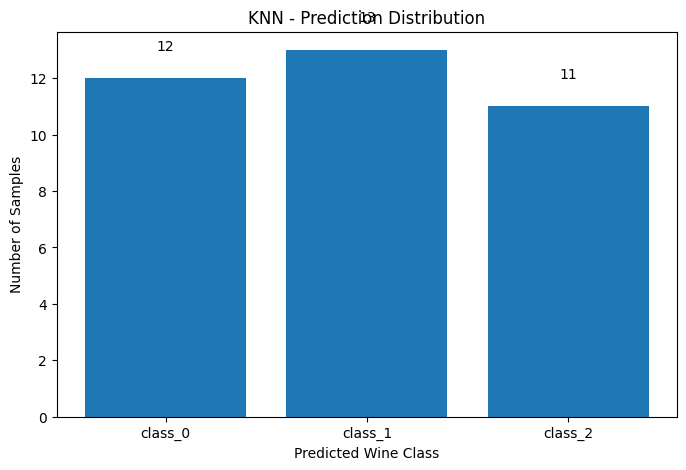

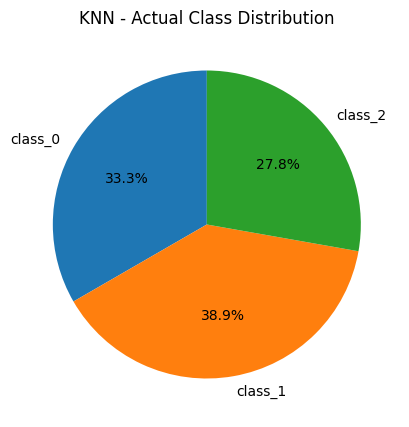

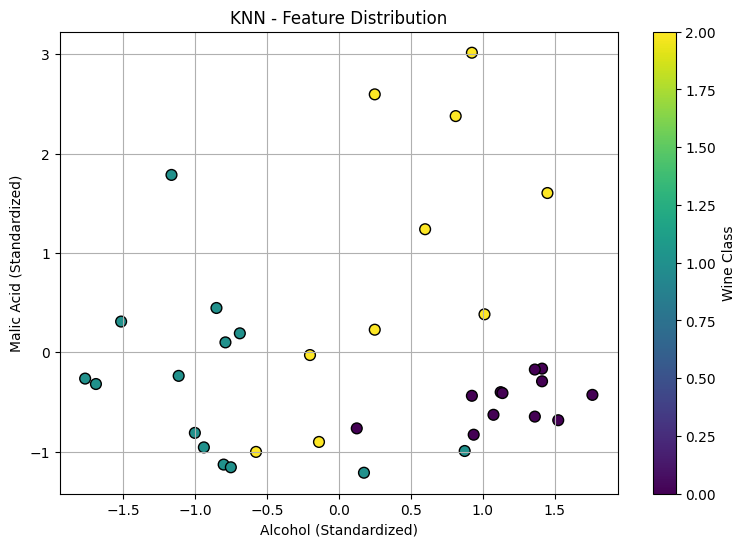


            FINAL RESULT
KNN Accuracy = 97.22%

Graphs Generated:
1. Prediction Distribution
2. Actual Class Distribution
3. KNN Feature Distribution


In [1]:
# ============================================================
# KNN MODEL - WINE DATASET
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_wine


# ------------------------------------------------------------
# 2. LOAD WINE DATASET
# ------------------------------------------------------------

wine = load_wine()

X = wine.data
y = wine.target

# Convert to DataFrame
df = pd.DataFrame(
    X,
    columns=wine.feature_names
)

df["target"] = y

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nTarget Classes:")
print(wine.target_names)


# ------------------------------------------------------------
# 3. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop("target", axis=1)

y = df["target"]


# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 5. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. CREATE KNN MODEL
# ------------------------------------------------------------

model = KNeighborsClassifier(
    n_neighbors=5
)


# ------------------------------------------------------------
# 7. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 8. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 9. CALCULATE ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("             KNN RESULTS")
print("======================================")

print(
    "Accuracy:",
    accuracy
)

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)


# ------------------------------------------------------------
# 10. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)


# ============================================================
# GRAPH 1 - PREDICTION DISTRIBUTION
# ============================================================

prediction_counts = pd.Series(
    y_pred
).value_counts().sort_index()


plt.figure(figsize=(8, 5))

plt.bar(
    wine.target_names,
    prediction_counts.values
)

plt.xlabel("Predicted Wine Class")

plt.ylabel("Number of Samples")

plt.title(
    "KNN - Prediction Distribution"
)

# Display values
for i, value in enumerate(
    prediction_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()


# ============================================================
# GRAPH 2 - ACTUAL CLASS DISTRIBUTION
# ============================================================

actual_counts = pd.Series(
    y_test
).value_counts().sort_index()


plt.figure(figsize=(7, 5))

plt.pie(
    actual_counts.values,
    labels=wine.target_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "KNN - Actual Class Distribution"
)

plt.show()


# ============================================================
# GRAPH 3 - KNN FEATURE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))


# Feature 1 = Alcohol
# Feature 2 = Malic Acid

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="viridis",
    s=60,
    edgecolors="black"
)


plt.xlabel(
    "Alcohol (Standardized)"
)

plt.ylabel(
    "Malic Acid (Standardized)"
)

plt.title(
    "KNN - Feature Distribution"
)

plt.colorbar(
    label="Wine Class"
)

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("            FINAL RESULT")
print("======================================")

print(
    f"KNN Accuracy = {accuracy * 100:.2f}%"
)

print("\nGraphs Generated:")
print("1. Prediction Distribution")
print("2. Actual Class Distribution")
print("3. KNN Feature Distribution")